# Deutsche Bahn × Actionable — Hybrid Predictive-Causal NPS Analysis

## Executive Summary

**Client:** Deutsche Bahn  
**Engagement:** Actionable NPS Driver Analytics  
**Analyst:** Senior ML Engineering  
**Dataset:** ~2 GB Train (survey respondents) · ~42 GB Live (314 M-row full population)

---

### Business Problem

Deutsche Bahn collects NPS surveys from a subset of their customers after each journey. The raw score alone answers *"how loyal is our customer base?"* but provides no actionable guidance. The real question is:

> **"If we invest in improving driver X by one tier, how much does the NPS needle actually move — and for which customer segment?"**

Answering that requires moving beyond correlation (SHAP-ranked feature importance) to **causal estimation** (Average Treatment Effects via T-Learner / IPW). This notebook executes the full hybrid pipeline end-to-end.

---

### Technical Architecture (5-Phase Plan)

| Phase | Scope | Key Tools |
|-------|-------|-----------|
| **1 — Data Engineering & EDA** | EAV pivot → wide; target/sparsity/correlation/covariate-shift analysis | Polars, Matplotlib, Seaborn |
| **2 — Feature Engineering** | Multi-categorical expansion (bounded CountVectorizer) | scikit-learn, Polars |
| **3 — Modeling & HPO** | Stratified Optuna on 20% sample; full LightGBM fit; Expected NPS | LightGBM, Optuna |
| **4 — Causal Inference** | SHAP pre-filter → T-Learner / IPW for true ATEs | SHAP, EconML / DoWhy |
| **5 — Live Inference** | Streaming 314 M rows → compressed Parquet | Polars LazyFrame |

---

### Driver Taxonomy (63 drivers across 12 contexts)

| Type | Count | Pipeline role |
|------|-------|---------------|
| `numeric` | 30 | Cast to `Float32`; fed raw to LightGBM; Spearman corr analysis |
| `categorical` | 30 | Cast to `pl.Categorical`; native LightGBM cat features |
| `multi_categorical` | 3 | Kept as `String`; expanded via limited CountVectorizer in Phase 2 |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path("..").resolve()))
from src.data_prep import parse_driver_definitions, load_and_pivot_data

# ── Plot aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13, "axes.labelsize": 11})

print(f"Polars  : {pl.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

Polars  : 1.36.1
NumPy   : 2.0.2
Pandas  : 2.3.3


In [2]:
# ── File paths ────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data")
DEFS_PATH  = DATA_DIR / "case_study_deutschebahn_driver_definitions.csv"
TRAIN_PATH = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_train.csv"
LIVE_PATH  = DATA_DIR / "case_study_deutschebahn_drivers_flat_users_live.csv"

# ── Parse driver definitions ──────────────────────────────────────────────
definitions_map = parse_driver_definitions(DEFS_PATH)

# Partition driver keys by type for easy downstream reference
numeric_drivers       = [k for k, v in definitions_map.items() if v == pl.Float32]
categorical_drivers   = [k for k, v in definitions_map.items() if v == pl.Categorical]
multi_cat_drivers     = [k for k, v in definitions_map.items() if v == pl.String]

print(f"Definitions loaded: {len(definitions_map)} drivers total")
print(f"  numeric          : {len(numeric_drivers)}")
print(f"  categorical      : {len(categorical_drivers)}")
print(f"  multi_categorical: {len(multi_cat_drivers)}")

Definitions loaded: 63 drivers total
  numeric          : 30
  categorical      : 30
  multi_categorical: 3


In [3]:
# ── Train: full eager load + pivot ────────────────────────────────────────
# The ~2 GB CSV is loaded entirely into memory as a wide DataFrame.
print("Loading Train dataset (full)...")
wide_train = load_and_pivot_data(TRAIN_PATH, definitions_map, is_lazy=False)
print(f"  Shape : {wide_train.shape[0]:,} customers × {wide_train.shape[1]} columns")
print(f"  Memory: {wide_train.estimated_size('mb'):.1f} MB")

# ── Live: lazy-scan sample of ≈100 k customers ────────────────────────────
# Each customer has ≤63 EAV rows, so 6.3M EAV rows ≈ 100k unique customers.
# This is sufficient for EDA-level covariate-shift testing; full 314M-row
# inference is handled in Phase 5 via a dedicated streaming pipeline.
LIVE_EAV_SAMPLE = 6_300_000
print(f"\nLoading Live sample ({LIVE_EAV_SAMPLE:,} EAV rows, lazy scan)...")
wide_live = load_and_pivot_data(
    LIVE_PATH, definitions_map, is_lazy=True, n_rows=LIVE_EAV_SAMPLE
)
print(f"  Shape : {wide_live.shape[0]:,} customers × {wide_live.shape[1]} columns")
print(f"  Memory: {wide_live.estimated_size('mb'):.1f} MB")

# Quick sanity check — confirm expected columns present
assert "npsScore" in wide_train.columns, "npsScore missing from Train"
assert "npsScore" not in wide_live.columns, "npsScore should not be in Live"
print("\nSchema sanity checks passed.")

Loading Train dataset (full)...
  Shape : 227,400 customers × 67 columns
  Memory: 73.8 MB

Loading Live sample (6,300,000 EAV rows, lazy scan)...
  Shape : 3,591,930 customers × 66 columns
  Memory: 1056.1 MB

Schema sanity checks passed.


---
## 0. Dataset Overview & Driver Profiling

**What we are looking for:**

Before diving into the target and modelling questions, we profile every driver column in the wide Train matrix to understand the *shape* of the feature space:

1. **Missingness range** — What is the min / median / max null rate across the 63 drivers? Are nulls concentrated in a few event-driven columns or spread evenly?
2. **Cardinality** — How many distinct values does each driver take? High-cardinality categoricals (e.g. route pairs) need different treatment from low-cardinality ones (e.g. gender). Multi-categorical drivers may encode comma-separated token lists.
3. **Type-specific summaries** — For numeric drivers: value range and spread on non-null observations. For categorical drivers: top modal categories.
4. **Cross-type comparison** — Do numeric drivers tend to be sparser than categorical ones, or vice versa?

This profiling step validates our Phase 2 feature-engineering strategy (bounded CountVectorizer for multi-categoricals, native LightGBM categoricals for the rest) and flags any drivers that may be degenerate (constant, near-empty, or single-valued).

Train customers : 227,400
Driver columns  : 63
Global sparsity : 26.7%

NUMERIC (30 drivers)
  Null % range     : 0.1% – 98.1%  (median 25.2%)
  Distinct values  : 2 – 22,591  (median 76)
  Mean (non-null)  : min=0.00, max=859.35

CATEGORICAL (30 drivers)
  Null % range     : 0.2% – 96.3%  (median 4.6%)
  Distinct values  : 2 – 166  (median 8)

MULTI_CATEGORICAL (3 drivers)
  Null % range     : 12.9% – 96.3%  (median 12.9%)
  Distinct values  : 2 – 115  (median 115)

Top 10 sparsest drivers
Driver                                                 Type                Null% #Distinct
------------------------------------------------------------------------
SumVoucherAmountV0Last30d                              numeric             98.1%       518
AverageVoucherAmountV0Last30d                          numeric             98.1%       543
AverageOrderOptionDistinctCategoryPerOrderV0Last30     numeric             98.1%         2
AverageOrderOptionAmountPerOrderV0Last30d              numeric     

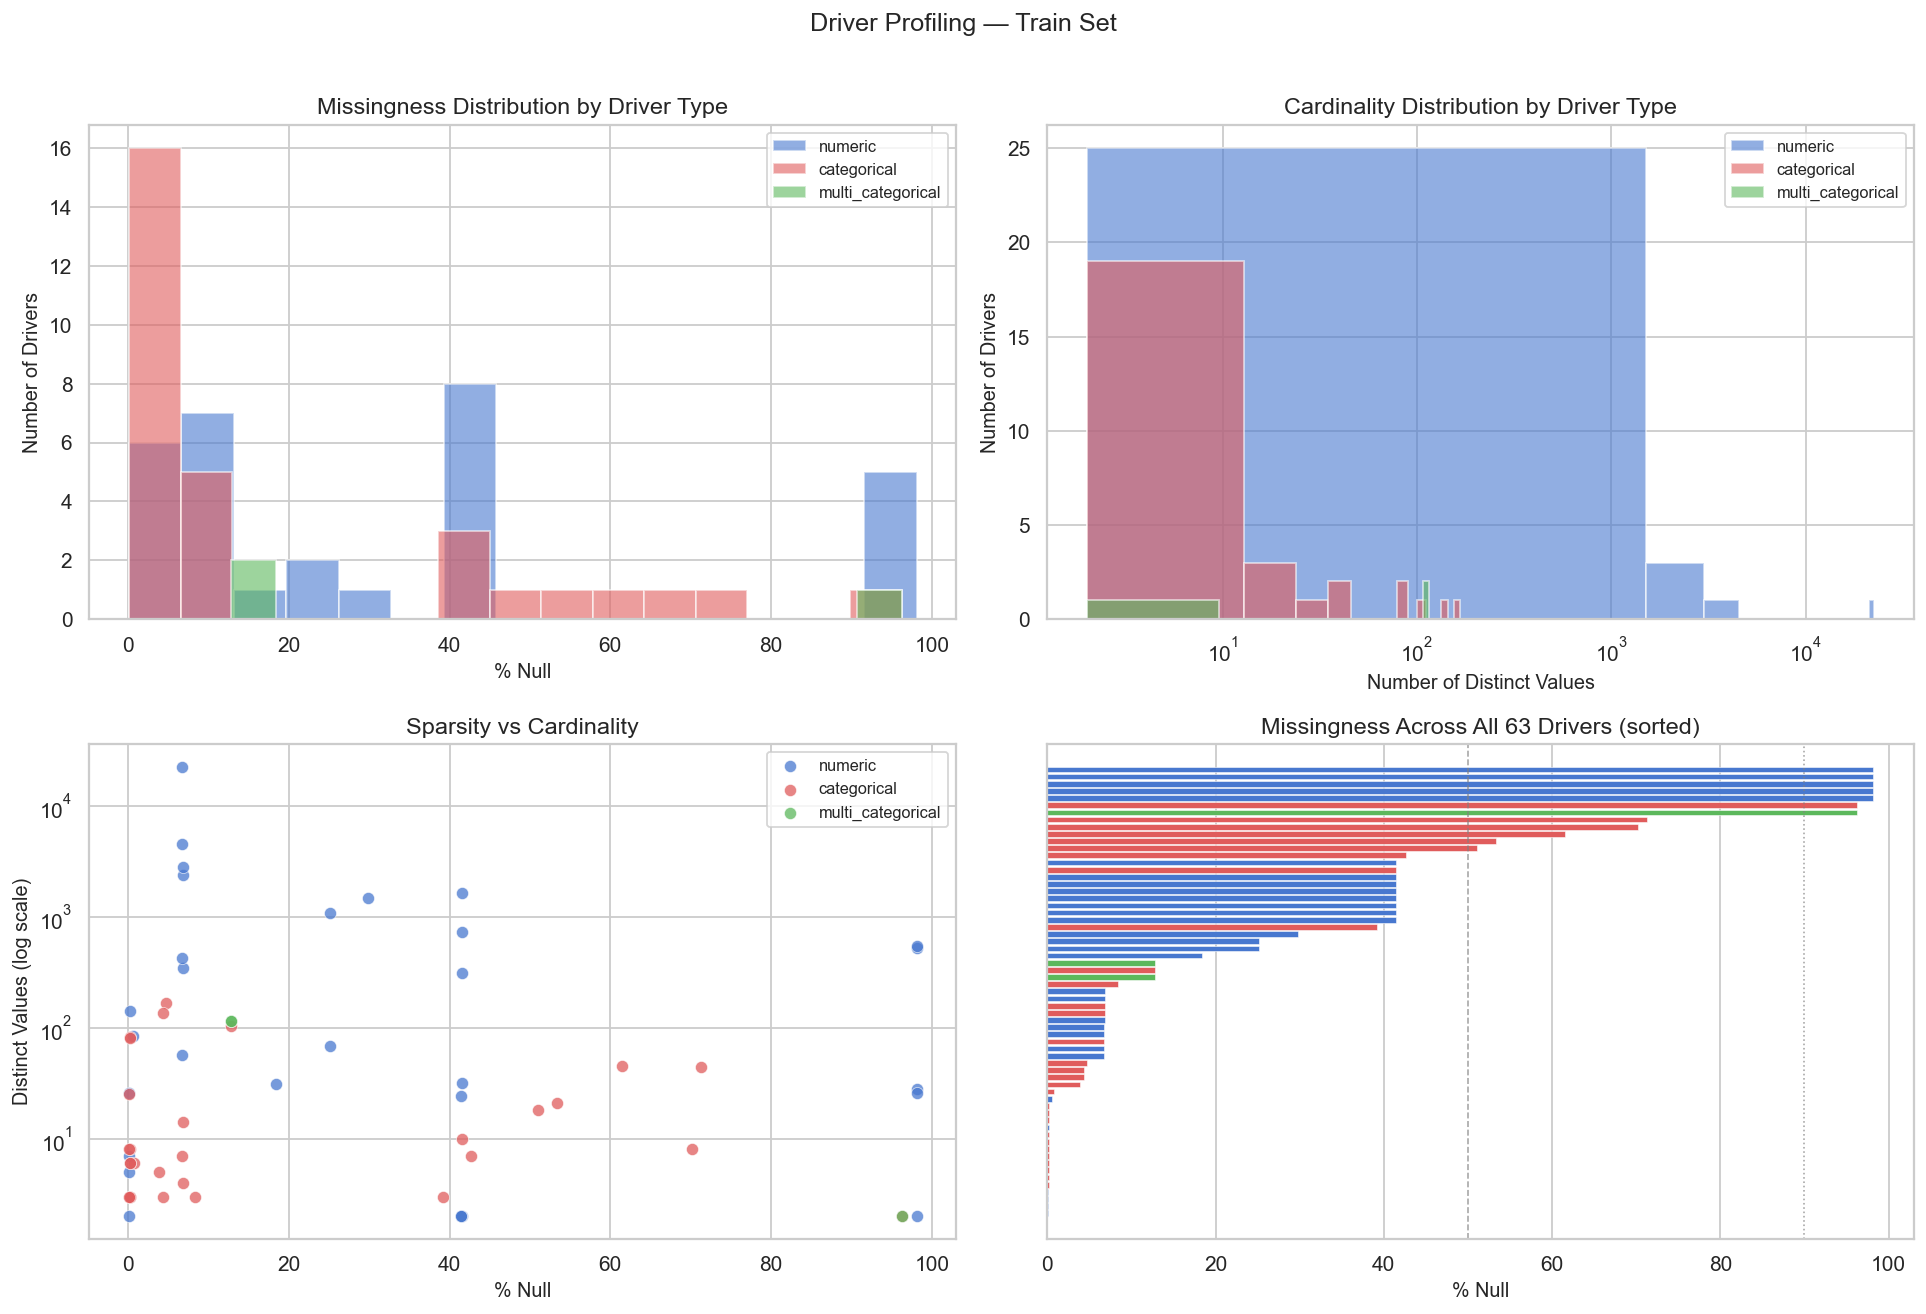


Degenerate drivers flagged (7): constant or >95% null
  • transactionalSumVoucherAmountV0Last30d  null=98.1%  distinct=518
  • transactionalAverageVoucherAmountV0Last30d  null=98.1%  distinct=543
  • transactionalAverageOrderOptionDistinctCategoryPerOrder  null=98.1%  distinct=2
  • transactionalAverageOrderOptionAmountPerOrderV0Last30d  null=98.1%  distinct=28
  • transactionalTotalOrderOptionAmountPerOrderV0Last30d  null=98.1%  distinct=26
  • transactionalMainOptionCombinationPerOrderV0  null=96.3%  distinct=2
  • transactionalLastOptionCombinationPerOrderV0  null=96.3%  distinct=2


In [4]:
# ── Driver columns (exclude metadata; nps_class not created yet) ───────────
META = {"sourceId", "sourceUniqueId", "npsDate", "npsScore"}
driver_cols = [c for c in wide_train.columns if c not in META]
n_customers = wide_train.height

def _driver_type(col: str) -> str:
    if col in numeric_drivers:
        return "numeric"
    if col in categorical_drivers:
        return "categorical"
    return "multi_categorical"

# ── Per-driver profile table ───────────────────────────────────────────────
profile_rows: list[dict] = []
for col in driver_cols:
    null_count = wide_train[col].is_null().sum()
    row: dict = {
        "driver": col,
        "driver_type": _driver_type(col),
        "null_pct": null_count / n_customers * 100,
        "n_non_null": n_customers - null_count,
        "n_distinct": wide_train[col].n_unique(),
    }
    if row["driver_type"] == "numeric":
        stats = wide_train.select(
            pl.col(col).min().alias("min"),
            pl.col(col).max().alias("max"),
            pl.col(col).mean().alias("mean"),
            pl.col(col).std().alias("std"),
        ).row(0, named=True)
        row.update(stats)
    profile_rows.append(row)

driver_profile = pd.DataFrame(profile_rows).sort_values("null_pct", ascending=False)

# Shared downstream (sections B & C reuse this)
null_pct: dict[str, float] = dict(zip(driver_profile["driver"], driver_profile["null_pct"]))

# ── Summary statistics by driver type ─────────────────────────────────────
print("=" * 72)
print(f"Train customers : {n_customers:,}")
print(f"Driver columns  : {len(driver_cols)}")
print(f"Global sparsity : {wide_train.select(driver_cols).null_count().sum_horizontal()[0] / (n_customers * len(driver_cols)) * 100:.1f}%")
print("=" * 72)

for dtype in ["numeric", "categorical", "multi_categorical"]:
    subset = driver_profile[driver_profile["driver_type"] == dtype]
    print(f"\n{dtype.upper()} ({len(subset)} drivers)")
    print(f"  Null % range     : {subset['null_pct'].min():.1f}% – {subset['null_pct'].max():.1f}%  (median {subset['null_pct'].median():.1f}%)")
    print(f"  Distinct values  : {subset['n_distinct'].min():,.0f} – {subset['n_distinct'].max():,.0f}  (median {subset['n_distinct'].median():.0f})")
    if dtype == "numeric":
        print(f"  Mean (non-null)  : min={subset['mean'].min():.2f}, max={subset['mean'].max():.2f}")

print("\n" + "=" * 72)
print("Top 10 sparsest drivers")
print(f"{'Driver':<55}{'Type':<18}{'Null%':>7}{'#Distinct':>10}")
print("-" * 72)
for _, r in driver_profile.head(10).iterrows():
    short = r["driver"].replace("transactional", "").replace("userProfile", "")[:50]
    print(f"{short:<55}{r['driver_type']:<18}{r['null_pct']:>6.1f}%{r['n_distinct']:>10,.0f}")

print("\nTop 10 highest-cardinality drivers")
print(f"{'Driver':<55}{'Type':<18}{'Null%':>7}{'#Distinct':>10}")
print("-" * 72)
for _, r in driver_profile.sort_values("n_distinct", ascending=False).head(10).iterrows():
    short = r["driver"].replace("transactional", "").replace("userProfile", "")[:50]
    print(f"{short:<55}{r['driver_type']:<18}{r['null_pct']:>6.1f}%{r['n_distinct']:>10,.0f}")
print("=" * 72)

# ── Visualisations ─────────────────────────────────────────────────────────
type_colors = {"numeric": "#4878CF", "categorical": "#E05C5C", "multi_categorical": "#5CB85C"}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1 — Null % distribution by driver type
for dtype, color in type_colors.items():
    subset = driver_profile[driver_profile["driver_type"] == dtype]
    axes[0, 0].hist(subset["null_pct"], bins=15, alpha=0.6, label=dtype, color=color, edgecolor="white")
axes[0, 0].set_xlabel("% Null")
axes[0, 0].set_ylabel("Number of Drivers")
axes[0, 0].set_title("Missingness Distribution by Driver Type")
axes[0, 0].legend(fontsize=9)

# 2 — Distinct-value count distribution by driver type (log scale)
for dtype, color in type_colors.items():
    subset = driver_profile[driver_profile["driver_type"] == dtype]
    axes[0, 1].hist(subset["n_distinct"], bins=15, alpha=0.6, label=dtype, color=color, edgecolor="white")
axes[0, 1].set_xlabel("Number of Distinct Values")
axes[0, 1].set_ylabel("Number of Drivers")
axes[0, 1].set_title("Cardinality Distribution by Driver Type")
axes[0, 1].set_xscale("log")
axes[0, 1].legend(fontsize=9)

# 3 — Scatter: null % vs cardinality (coloured by type)
for dtype, color in type_colors.items():
    subset = driver_profile[driver_profile["driver_type"] == dtype]
    axes[1, 0].scatter(
        subset["null_pct"], subset["n_distinct"],
        alpha=0.75, s=45, label=dtype, color=color, edgecolors="white", linewidth=0.4,
    )
axes[1, 0].set_xlabel("% Null")
axes[1, 0].set_ylabel("Distinct Values (log scale)")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Sparsity vs Cardinality")
axes[1, 0].legend(fontsize=9)

# 4 — Bar chart: null % for all drivers (sorted)
sorted_profile = driver_profile.sort_values("null_pct", ascending=True)
bar_colors = [type_colors[t] for t in sorted_profile["driver_type"]]
axes[1, 1].barh(
    range(len(sorted_profile)),
    sorted_profile["null_pct"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.3,
)
axes[1, 1].set_yticks([])
axes[1, 1].set_xlabel("% Null")
axes[1, 1].set_title("Missingness Across All 63 Drivers (sorted)")
axes[1, 1].axvline(50, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
axes[1, 1].axvline(90, color="gray", linestyle=":", linewidth=0.9, alpha=0.7)

plt.suptitle("Driver Profiling — Train Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Degenerate-driver flags ──────────────────────────────────────────────────
degenerate = driver_profile[
    (driver_profile["n_distinct"] <= 1) | (driver_profile["null_pct"] > 95)
].copy()
if len(degenerate):
    print(f"\nDegenerate drivers flagged ({len(degenerate)}): constant or >95% null")
    for _, r in degenerate.iterrows():
        print(f"  • {r['driver'][:55]}  null={r['null_pct']:.1f}%  distinct={r['n_distinct']:.0f}")
else:
    print("\nNo degenerate drivers flagged (constant or >95% null).")

### Business Conclusion — 0. Dataset Overview

> ✏️ *Write your interpretation here after running the cell above.*
>
> Suggested prompts:
> - What is the overall null-rate range, and which driver types are sparsest?
> - Which drivers have extreme cardinality (e.g. route pairs) and will need special handling in Phase 2?
> - Are any degenerate drivers (constant or near-empty) worth dropping before modelling?
> - Does the sparsity/cardinality scatter reveal clusters that map to business domains (Payment, Travel, Delay)?

---
## A. Target Analysis & Class Balance

**What we are looking for:**

The raw `npsScore` takes exactly three integer values in this dataset — `0`, `7`, and `10` — which map to the standard NPS segments:

| Raw score | Segment | `nps_class` label |
|-----------|---------|-------------------|
| 0 | Detractor | 0 |
| 7 | Passive / Neutral | 1 |
| 10 | Promoter | 2 |

We want to confirm the **class distribution** in the Train set. If the three segments are roughly balanced, no class re-weighting is needed for LightGBM — we can rely on Macro F1-Score as the Optuna objective without `class_weight` adjustments. If one class dominates, that would motivate re-weighting or stratified sampling; in this dataset we expect approximate balance.

Class                      Count     Share
---------------------------------------------
Detractor (0)             71,378     31.4%
Passive (7)               64,454     28.3%
Promoter (10)             91,568     40.3%

Max deviation from uniform (33.3%): 6.9 pp
No class_weight adjustments needed — dataset is approximately balanced.


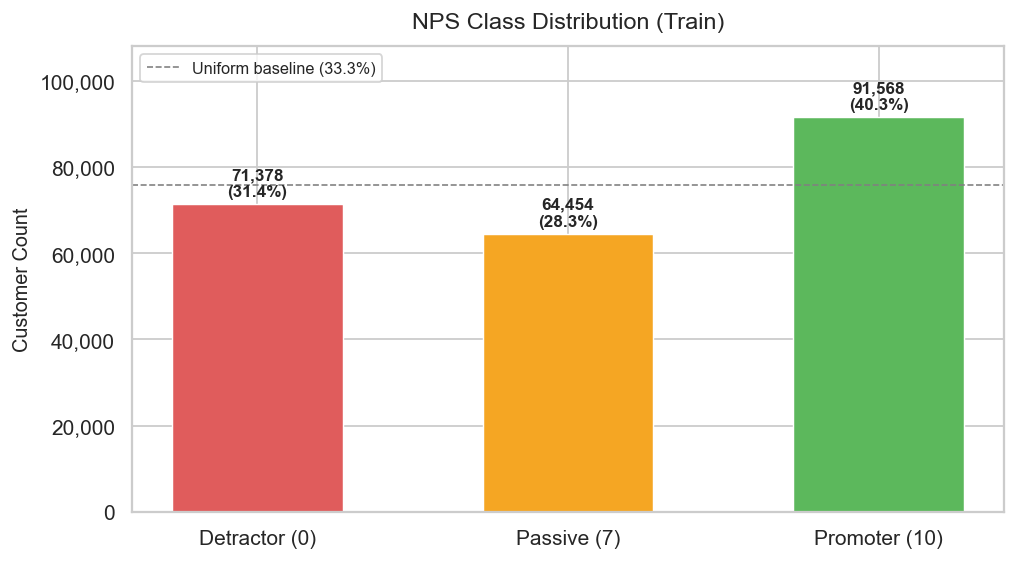

In [5]:
# ── Map npsScore → nps_class ───────────────────────────────────────────────
wide_train = wide_train.with_columns(
    pl.when(pl.col("npsScore") == 0).then(pl.lit(0))
      .when(pl.col("npsScore") == 7).then(pl.lit(1))
      .when(pl.col("npsScore") == 10).then(pl.lit(2))
      .otherwise(pl.lit(-1))
      .cast(pl.Int8)
      .alias("nps_class")
)

# ── Class counts & proportions ─────────────────────────────────────────────
class_labels = {0: "Detractor (0)", 1: "Passive (7)", 2: "Promoter (10)"}
class_colors = {0: "#E05C5C", 1: "#F5A623", 2: "#5CB85C"}

counts = (
    wide_train
    .group_by("nps_class")
    .agg(pl.len().alias("n"))
    .sort("nps_class")
)
n_total = wide_train.height
counts_dict = dict(zip(counts["nps_class"].to_list(), counts["n"].to_list()))
class_order = [0, 1, 2]
class_n   = [counts_dict.get(c, 0) for c in class_order]
class_pct = [n / n_total * 100 for n in class_n]

# ── Print summary ──────────────────────────────────────────────────────────
print("=" * 45)
print(f"{'Class':<22}{'Count':>10}{'Share':>10}")
print("-" * 45)
for c in class_order:
    print(f"{class_labels[c]:<22}{class_n[c]:>10,}{class_pct[c]:>9.1f}%")
print("=" * 45)

max_deviation = max(abs(p - 100 / 3) for p in class_pct)
print(f"\nMax deviation from uniform (33.3%): {max_deviation:.1f} pp")
print("No class_weight adjustments needed — dataset is approximately balanced.")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    [class_labels[c] for c in class_order],
    class_n,
    color=[class_colors[c] for c in class_order],
    edgecolor="white",
    linewidth=0.8,
    width=0.55,
)
for bar, n, pct in zip(bars, class_n, class_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + n_total * 0.005,
        f"{n:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax.axhline(n_total / 3, color="gray", linestyle="--", linewidth=0.9, label="Uniform baseline (33.3%)")
ax.set_title("NPS Class Distribution (Train)", pad=10)
ax.set_ylabel("Customer Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, max(class_n) * 1.18)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Business Conclusion — A. Target Analysis

> ✏️ *Write your interpretation here after running the cell above.*
>
> Suggested prompts:
> - Are all three NPS classes roughly equal (~33% each)?
> - Does the max deviation from uniform confirm that no class re-weighting is needed?
> - Any unexpected scores outside {0, 7, 10} flagged by the `-1` sentinel?

---
## B. Sparsity & Missingness Matrix

**What we are looking for:**

In event-driven CRM data, missingness is almost never Missing At Random (MAR). A customer with a null on `transactionalAverageVoucherAmountV0Last30d` has not simply not been measured — they genuinely had no voucher usage in the window. The null *is* the signal.

We are interested in two structural questions:

1. **Overall sparsity** — What fraction of cells in the wide Train matrix are null? High global sparsity (>40%) confirms that tree-based models are the right family: LightGBM propagates null splits natively, eliminating the need for complex imputation pipelines that could introduce spurious patterns.

2. **Per-driver null rate distribution** — Are the nulls concentrated in a few pathological features, or spread evenly? Features with >90% nulls are dangerous for causal inference even if LightGBM tolerates them predictively, because effective sample sizes for treatment/control comparisons become vanishingly small.

**Architectural implication highlighted:** The histogram of null percentages is the single strongest justification for choosing LightGBM over logistic regression or linear SVMs, which cannot handle structural missingness without imputation.

  Global sparsity     : 26.7%
  Total driver columns: 63
--------------------------------------------------
  Extreme (>90%)        :   7 features
  High (50–90%)         :   5 features
  Moderate (10–50%)     :  18 features
  Low (<10%)            :  33 features


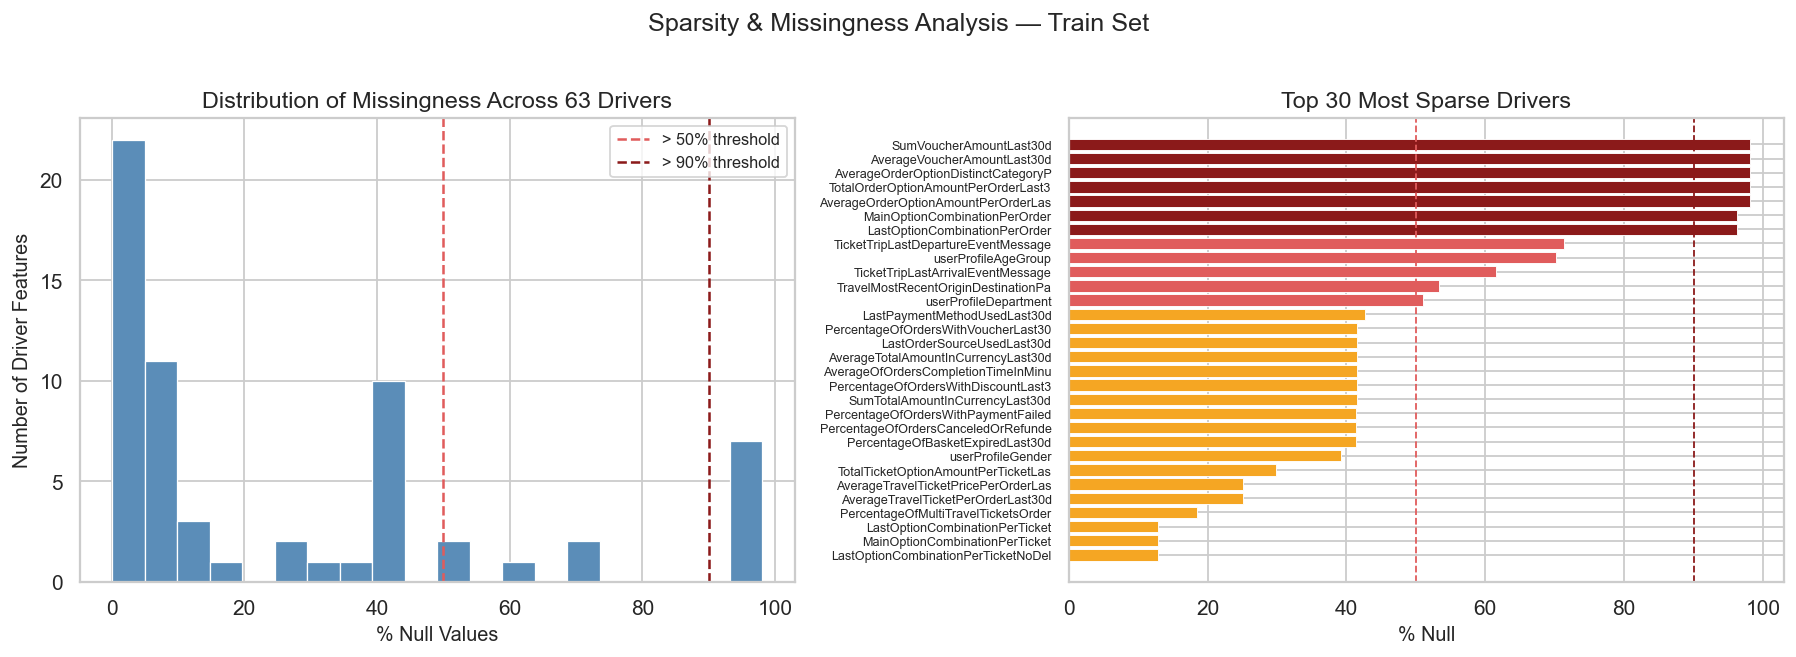

In [6]:
# Reuses driver_cols and null_pct computed in Section 0
n_drivers = len(driver_cols)

null_series = pd.Series(null_pct, name="null_pct").sort_values(ascending=False)

# Thresholds for annotation
thresholds = {
    "Extreme (>90%)": (null_series > 90).sum(),
    "High (50–90%)":  ((null_series >= 50) & (null_series <= 90)).sum(),
    "Moderate (10–50%)": ((null_series >= 10) & (null_series < 50)).sum(),
    "Low (<10%)":     (null_series < 10).sum(),
}

global_sparsity = wide_train.select(driver_cols).null_count().sum_horizontal()[0] / (n_customers * n_drivers) * 100

print("=" * 50)
print(f"  Global sparsity     : {global_sparsity:.1f}%")
print(f"  Total driver columns: {n_drivers}")
print("-" * 50)
for tier, cnt in thresholds.items():
    print(f"  {tier:<22}: {cnt:>3} features")
print("=" * 50)

# ── Plot: histogram of null percentages ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of missingness distribution across features
axes[0].hist(
    null_series.values,
    bins=20,
    color="#5B8DB8",
    edgecolor="white",
    linewidth=0.7,
)
axes[0].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.4, label="> 50% threshold")
axes[0].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.4, label="> 90% threshold")
axes[0].set_xlabel("% Null Values")
axes[0].set_ylabel("Number of Driver Features")
axes[0].set_title("Distribution of Missingness Across 63 Drivers")
axes[0].legend(fontsize=9)

# Right: bar chart sorted by null % (top 30 most sparse)
top_n = 30
top_null = null_series.head(top_n)
bar_colors = [
    "#8B1A1A" if v > 90 else "#E05C5C" if v > 50 else "#F5A623" if v > 10 else "#5CB85C"
    for v in top_null.values
]
axes[1].barh(
    range(top_n),
    top_null.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5,
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(
    [col.replace("transactional", "").replace("V0", "").replace("V1", "")[:35]
     for col in top_null.index],
    fontsize=7,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("% Null")
axes[1].set_title(f"Top {top_n} Most Sparse Drivers")
axes[1].axvline(50, color="#E05C5C", linestyle="--", linewidth=1.0)
axes[1].axvline(90, color="#8B1A1A", linestyle="--", linewidth=1.0)

plt.suptitle("Sparsity & Missingness Analysis — Train Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Business Conclusion — B. Sparsity & Missingness

> ✏️ *Write your interpretation here after running the cell above.*
>
> Suggested prompts:
> - What is the overall global sparsity, and does it exceed 40%?
> - Which specific drivers have >90% missingness — are they conceptually narrow (e.g. voucher metrics only apply to voucher users)?
> - Does the sparsity pattern validate LightGBM as the right model family (vs. imputation-heavy alternatives)?
> - Are any causal candidates dangerously sparse for ATE estimation?

---
## C. Feature Correlation & Multicollinearity

**What we are looking for:**

We compute **Spearman** and **Pearson** correlation matrices across all numeric drivers that pass quality filters (>80% non-null, non-zero variance).

| Method | When it matters |
|--------|-----------------|
| **Spearman (rank)** | Robust to skew and outliers; preferred for ordinal or heavy-tailed behaviour metrics (delay duration, voucher amounts). |
| **Pearson (linear)** | Surfaces strictly linear co-movement; useful to compare against Spearman — if Pearson ≈ Spearman, the relationship is monotonic and roughly linear; if they diverge, the association is non-linear. |

Both matrices use hierarchical Ward clustering on the correlation rows to surface redundant feature groups. We are specifically hunting for:

- **Window-redundancy** — Do `Last7d` and `Last30d` versions of the same metric collapse into a ρ ≈ 1 cluster? If so, keeping both inflates SHAP importance without adding true signal.
- **Cross-domain correlations** — Do Delay metrics correlate with Cancellation/Refund metrics? High correlation may indicate a shared latent construct, making causal isolation difficult in Phase 4.
- **Near-zero correlations** — Features orthogonal to everything else are good independent causal treatment candidates.

**Note:** Pairwise complete observations are used for each cell. Features with >80% missingness or zero variance are excluded to avoid undefined correlations that break clustering.

Numeric drivers present       : 30
After >80% null filter        : 25
Dropped 4 zero-variance column(s): ['PercentageOfBasketExpired', 'CountOrdersWithDiscount', 'PercentageOfOrdersWithPaymentFailedOrPending', 'PercentageOfOrdersWithDiscount']
After zero-variance filter    : 21


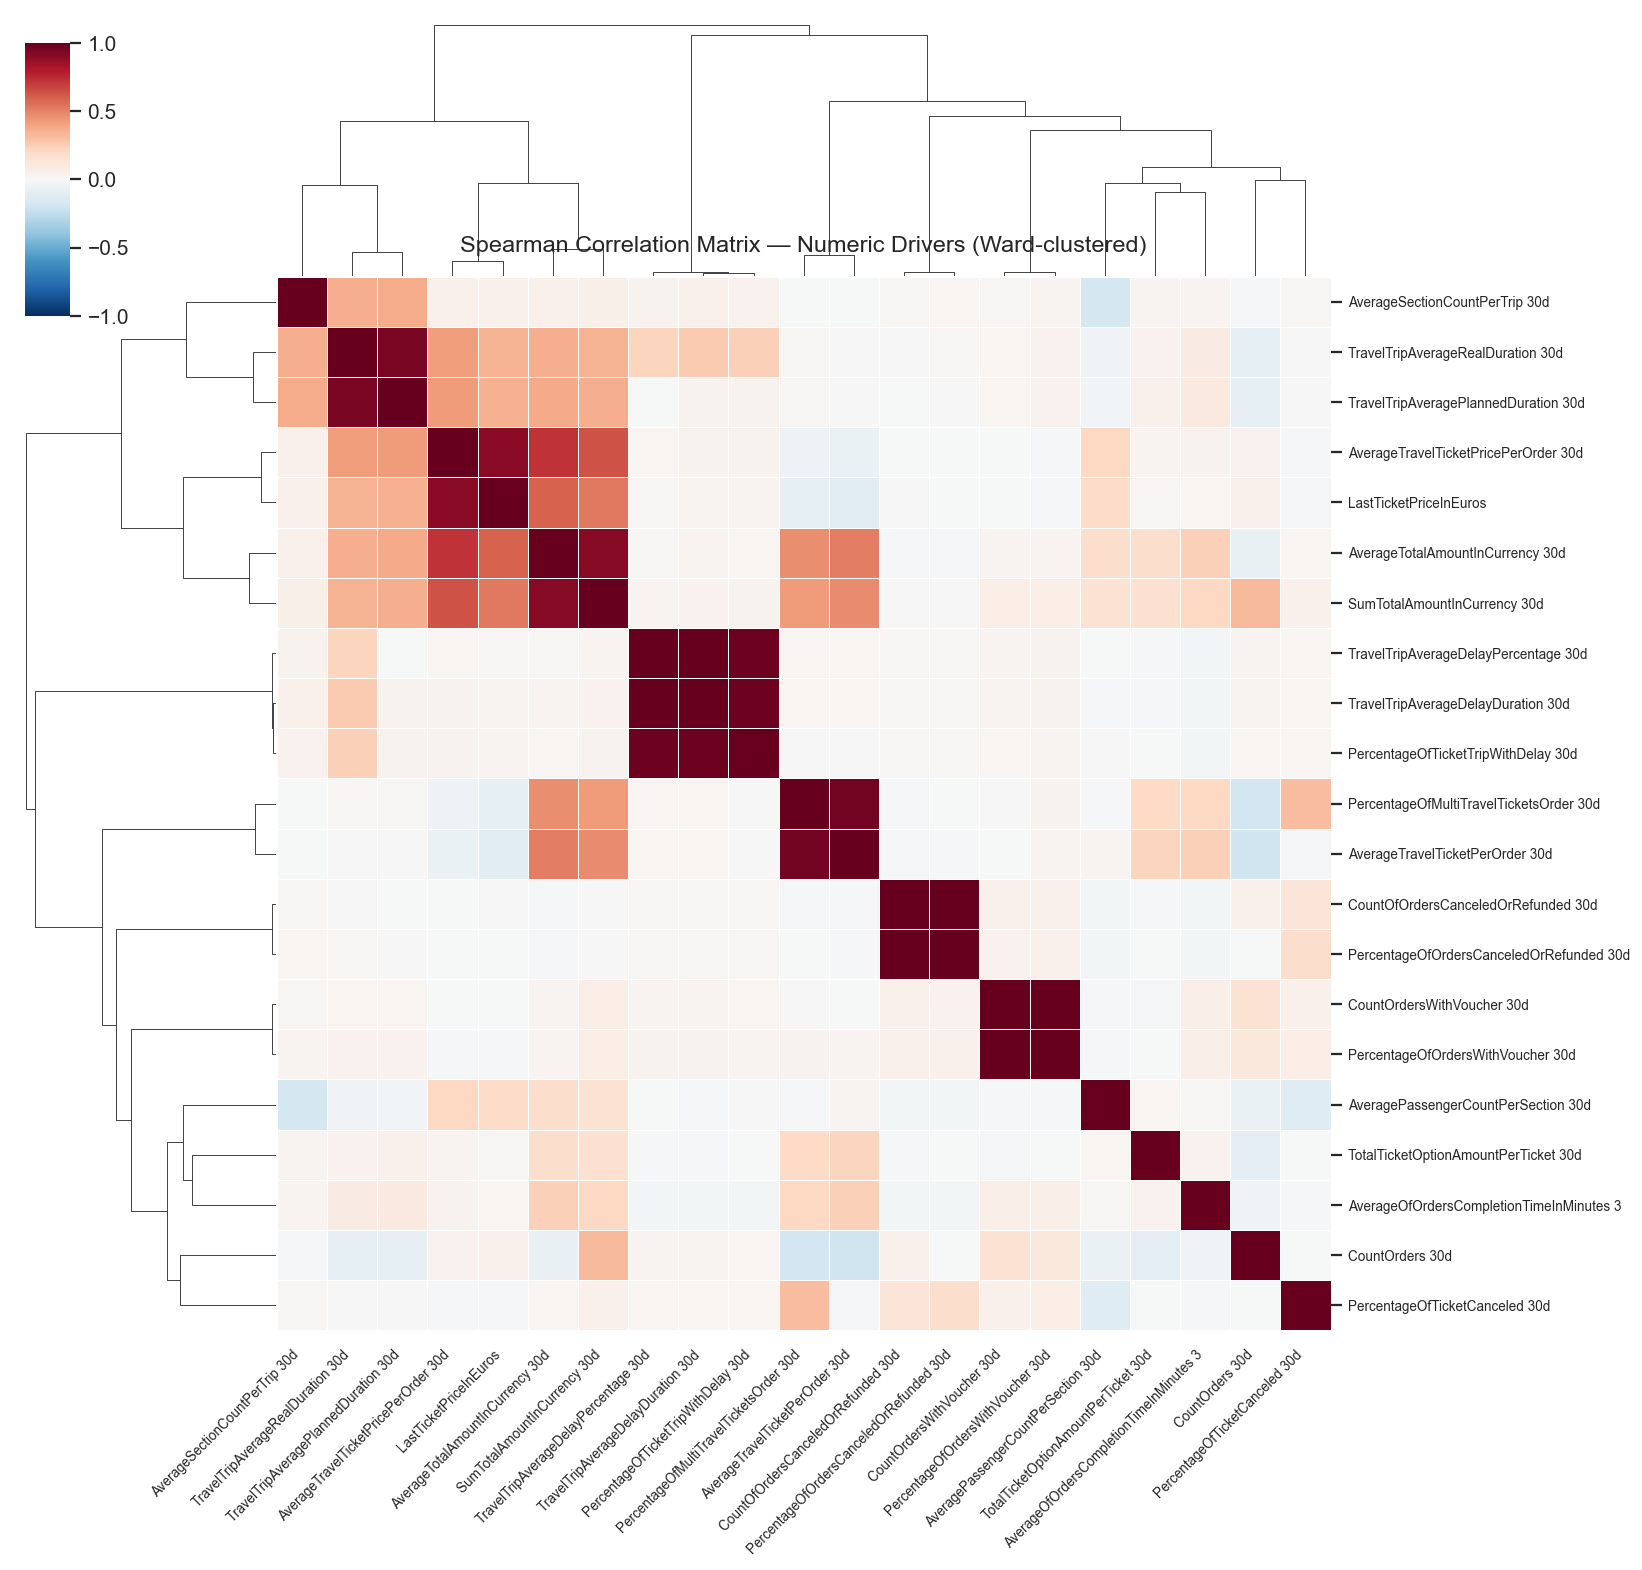

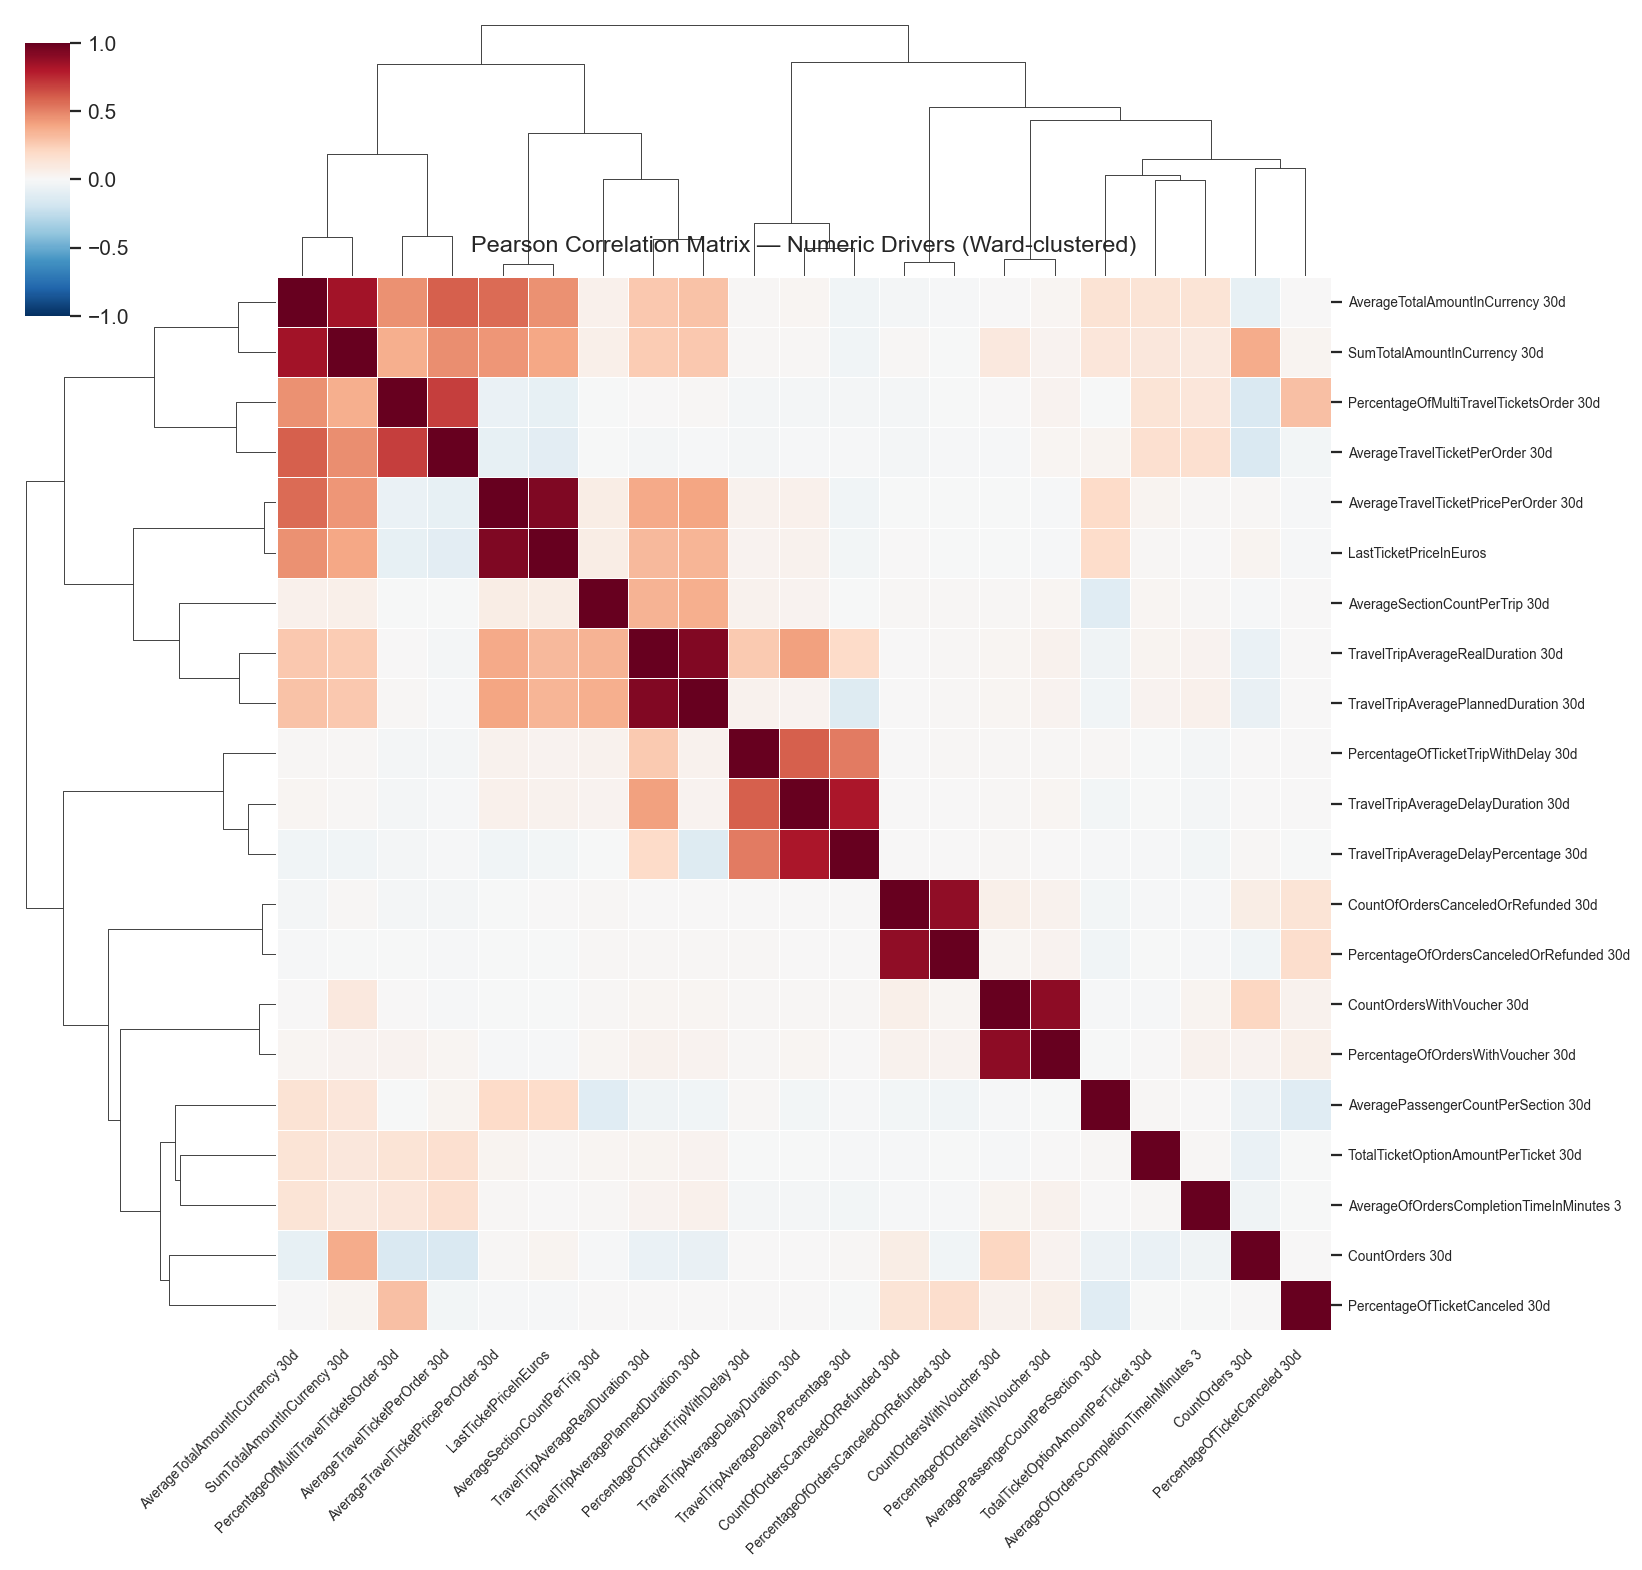


Spearman — high-correlation pairs (|ρ| > 0.85): 9 found
  Feature A                              Feature B                                   ρ
  --------------------------------------------------------------------------------------
  CountOfOrdersCanceledOrRefunded 30d    PercentageOfOrdersCanceledOrRefunded 30d +1.000
  CountOrdersWithVoucher 30d             PercentageOfOrdersWithVoucher 30d      +1.000
  TravelTripAverageDelayDuration 30d     TravelTripAverageDelayPercentage 30d   +0.996
  TravelTripAverageDelayDuration 30d     PercentageOfTicketTripWithDelay 30d    +0.980
  TravelTripAverageDelayPercentage 30d   PercentageOfTicketTripWithDelay 30d    +0.979
  PercentageOfMultiTravelTicketsOrder 30d AverageTravelTicketPerOrder 30d        +0.965
  TravelTripAverageRealDuration 30d      TravelTripAveragePlannedDuration 30d   +0.949
  AverageTotalAmountInCurrency 30d       SumTotalAmountInCurrency 30d           +0.907
  AverageTravelTicketPricePerOrder 30d   LastTicketPriceInEuros     

In [7]:
# ── Select numeric drivers that appear in the wide Train DataFrame ─────────
present_numeric = [c for c in numeric_drivers if c in wide_train.columns]

sparse_filtered = [
    c for c in present_numeric
    if null_pct.get(c, 100) <= 80
]
print(f"Numeric drivers present       : {len(present_numeric)}")
print(f"After >80% null filter        : {len(sparse_filtered)}")

numeric_pd: pd.DataFrame = (
    wide_train
    .select(sparse_filtered)
    .to_pandas()
)

# Drop zero-variance columns (undefined correlation → breaks clustermap)
zero_var_cols = [c for c in sparse_filtered if numeric_pd[c].dropna().std() == 0]
valid_numeric = [c for c in sparse_filtered if c not in set(zero_var_cols)]

if zero_var_cols:
    short_zv = [c.replace("transactional", "").replace("V0Last30d", "")[:45]
                for c in zero_var_cols]
    print(f"Dropped {len(zero_var_cols)} zero-variance column(s): {short_zv}")

numeric_pd = numeric_pd[valid_numeric]
print(f"After zero-variance filter    : {len(valid_numeric)}")

# ── Correlation matrices ───────────────────────────────────────────────────
corr_spearman: pd.DataFrame = numeric_pd.corr(method="spearman")
corr_pearson: pd.DataFrame  = numeric_pd.corr(method="pearson")

def _short_label(col: str) -> str:
    label = col.replace("transactional", "").replace("userProfile", "")
    label = label.replace("V0Last30d", " 30d").replace("V1Last30d", " 30d")
    label = label.replace("V0Last180d", " 180d").replace("V0", "")
    return label[:40]

short_labels = [_short_label(c) for c in valid_numeric]
for corr in (corr_spearman, corr_pearson):
    corr.index = short_labels
    corr.columns = short_labels

def _plot_corr_clustermap(corr_matrix: pd.DataFrame, title: str) -> None:
    n_feats = len(valid_numeric)
    fig_size = max(14, n_feats * 0.55)
    g = sns.clustermap(
        corr_matrix,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(fig_size, fig_size),
        annot=n_feats <= 20,
        fmt=".2f",
        linewidths=0.4,
        linecolor="white",
        cbar_pos=(0.02, 0.82, 0.025, 0.15),
        method="ward",
        metric="euclidean",
    )
    g.ax_heatmap.set_title(title, fontsize=13, pad=14)
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=7.5
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7.5
    )
    plt.show()

def _high_corr_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.85) -> list[tuple]:
    pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i + 1, len(corr_matrix)):
            rho = corr_matrix.iloc[i, j]
            if abs(rho) > threshold:
                pairs.append((corr_matrix.index[i], corr_matrix.columns[j], rho))
    return pairs

# ── Spearman heatmap ───────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_spearman,
    "Spearman Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── Pearson heatmap ────────────────────────────────────────────────────────
_plot_corr_clustermap(
    corr_pearson,
    "Pearson Correlation Matrix — Numeric Drivers (Ward-clustered)",
)

# ── High-correlation pairs for both methods ────────────────────────────────
for method_name, corr_matrix in [("Spearman", corr_spearman), ("Pearson", corr_pearson)]:
    high_corr_pairs = _high_corr_pairs(corr_matrix)
    if high_corr_pairs:
        print(f"\n{method_name} — high-correlation pairs (|ρ| > 0.85): {len(high_corr_pairs)} found")
        print(f"  {'Feature A':<38} {'Feature B':<38} {'ρ':>6}")
        print("  " + "-" * 86)
        for a, b, rho in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
            print(f"  {a:<38} {b:<38} {rho:>+6.3f}")
    else:
        print(f"\n{method_name} — no feature pairs with |ρ| > 0.85 found.")

### Business Conclusion — C. Feature Correlation & Multicollinearity

> ✏️ *Write your interpretation here after running the cell above.*
>
> Suggested prompts:
> - Do Spearman and Pearson clusterings agree, or do they reveal different structure (non-linear vs linear relationships)?
> - Do any feature clusters map to a coherent business domain (e.g. all Delay metrics clustering together)?
> - Are there ρ > 0.85 pairs in either matrix that indicate redundancy? Which one in each pair should be retained for the causal analysis?
> - Which numeric features appear most isolated (low correlation with everything) — good causal treatment candidates?

---
## D. Covariate Shift Check — The Selection Bias Hypothesis

**What we are looking for:**

The Train set is composed exclusively of customers who *responded to an NPS survey*. Survey response is not random: frequent travellers, customers who experienced a problem, or customers in a specific age group are all systematically more likely to respond. This is the classic **Voluntary Response Bias**.

If the distribution of any feature `X` in the Train set differs significantly from its distribution in the Live population, then:

- The model trained on Train will learn a decision boundary calibrated to the *survey-responding* subpopulation.
- When we score the full 314 M-row Live population, the predicted NPS distribution will be biased.
- Causal estimates derived from the biased Train set will overstate or understate ATEs for the broader population.

**Remedy (Phase 5):** If this shift is severe, we apply **Propensity Score Weighting** when training: we train a binary classifier to predict `P(in_train | X)` and re-weight training samples by `1 / P(in_train | X)` (IPW), effectively making the Train gradient updates representative of the Live distribution.

**Current analysis:** We overlay KDE plots of two core numeric drivers for the Train set vs. the Live sample to visually detect distributional drift. We focus on:
1. `Average Delay Duration (30d)` — operational driver with direct survey-response confounder risk (delayed passengers complain more).
2. `Average Ticket Price per Order (30d)` — socioeconomic proxy that often correlates with survey response propensity.

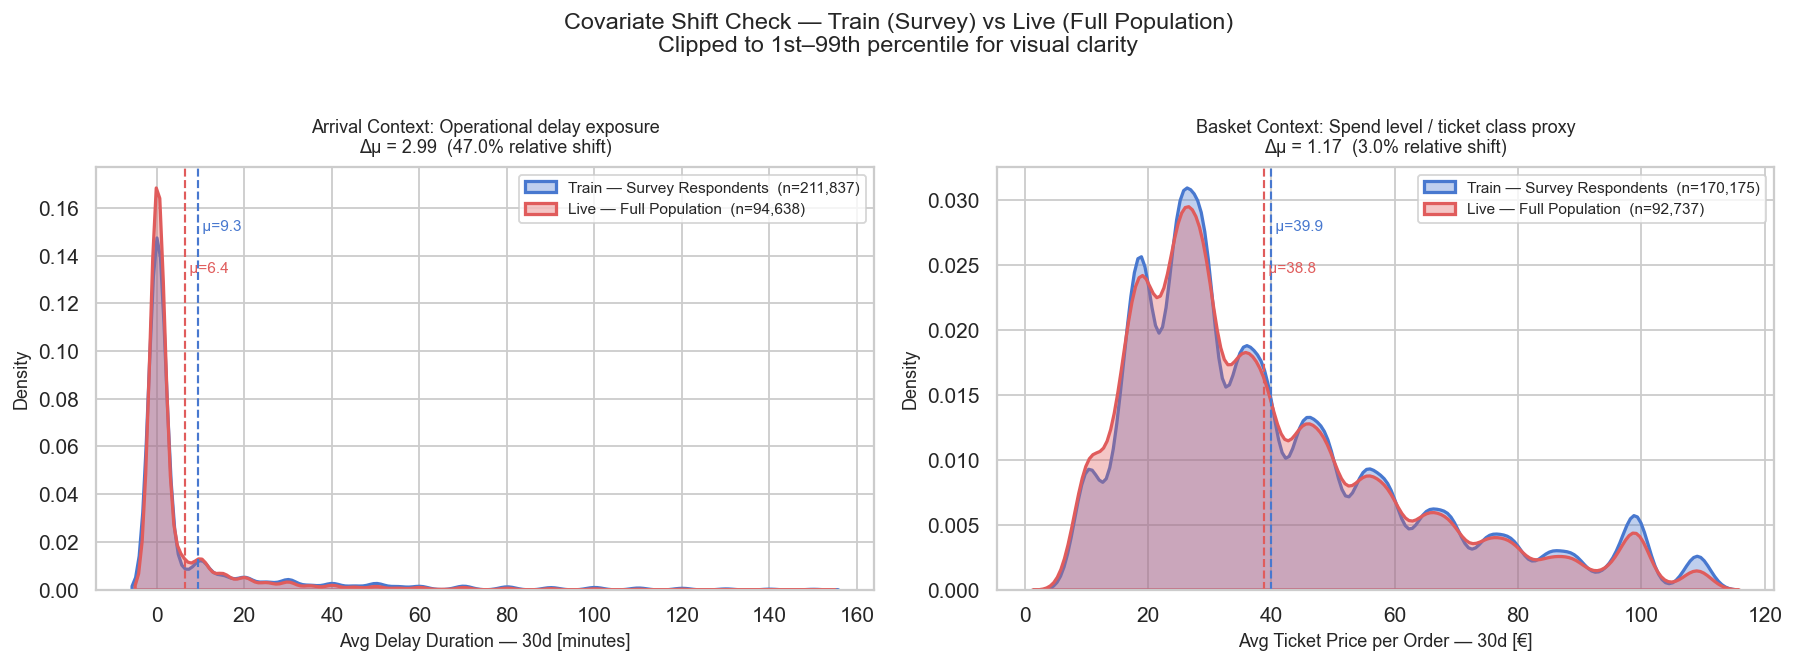


Summary Statistics Comparison

  TravelTripAverageDelayDuration
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             11.092        7.077        4.015
  median            0.000        0.000        0.000
  std              29.966       23.041        6.925
  p95              60.000       40.000       20.000

  AverageTravelTicketPricePerOrd
  Stat              Train         Live      Δ (abs)
  ------------------------------------------------
  mean             40.436       38.808        1.629
  median           35.000       32.000        3.000
  std              23.932       23.101        0.831
  p95              95.000       89.000        6.000


In [8]:
# ── Features & display config for the shift check ─────────────────────────
SHIFT_FEATURES = [
    (
        "transactionalTravelTripAverageDelayDurationV0Last30d",
        "Avg Delay Duration — 30d [minutes]",
        "Arrival Context: Operational delay exposure",
    ),
    (
        "transactionalAverageTravelTicketPricePerOrderV1Last30d",
        "Avg Ticket Price per Order — 30d [€]",
        "Basket Context: Spend level / ticket class proxy",
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat, x_label, subtitle) in zip(axes, SHIFT_FEATURES):
    train_vals = wide_train[feat].drop_nulls().to_numpy()
    live_vals  = wide_live[feat].drop_nulls().to_numpy() if feat in wide_live.columns else np.array([])

    if len(train_vals) == 0:
        ax.text(0.5, 0.5, "No data in Train", transform=ax.transAxes, ha="center")
        continue
    if len(live_vals) == 0:
        ax.text(0.5, 0.5, "Feature absent in Live sample", transform=ax.transAxes, ha="center")
        continue

    # Clip extreme outliers for plot readability (1st–99th percentile)
    lo = min(np.percentile(train_vals, 1), np.percentile(live_vals, 1))
    hi = max(np.percentile(train_vals, 99), np.percentile(live_vals, 99))
    train_clipped = train_vals[(train_vals >= lo) & (train_vals <= hi)]
    live_clipped  = live_vals[(live_vals >= lo)  & (live_vals <= hi)]

    sns.kdeplot(
        train_clipped,
        ax=ax,
        label=f"Train — Survey Respondents  (n={len(train_vals):,})",
        color="#4878CF",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )
    sns.kdeplot(
        live_clipped,
        ax=ax,
        label=f"Live — Full Population  (n={len(live_vals):,})",
        color="#E05C5C",
        fill=True,
        alpha=0.35,
        linewidth=1.8,
    )

    # Annotate mean lines
    train_mean = train_clipped.mean()
    live_mean  = live_clipped.mean()
    ax.axvline(train_mean, color="#4878CF", linestyle="--", linewidth=1.2)
    ax.axvline(live_mean,  color="#E05C5C", linestyle="--", linewidth=1.2)
    ax.text(train_mean, ax.get_ylim()[1] * 0.85, f" μ={train_mean:.1f}", color="#4878CF", fontsize=8.5)
    ax.text(live_mean,  ax.get_ylim()[1] * 0.75, f" μ={live_mean:.1f}",  color="#E05C5C", fontsize=8.5)

    # Δμ annotation
    delta = abs(train_mean - live_mean)
    rel_delta = delta / (abs(live_mean) + 1e-9) * 100
    ax.set_title(
        f"{subtitle}\nΔμ = {delta:.2f}  ({rel_delta:.1f}% relative shift)",
        fontsize=10, pad=8,
    )
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8.5, loc="upper right")

plt.suptitle(
    "Covariate Shift Check — Train (Survey) vs Live (Full Population)\n"
    "Clipped to 1st–99th percentile for visual clarity",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Population-level summary statistics for the two features ──────────────
print("\nSummary Statistics Comparison")
print("=" * 72)
for feat, x_label, _ in SHIFT_FEATURES:
    t = wide_train[feat].drop_nulls().to_numpy() if feat in wide_train.columns else np.array([])
    l = wide_live[feat].drop_nulls().to_numpy()  if feat in wide_live.columns  else np.array([])
    short = feat.replace("transactional", "").replace("V0Last30d", "").replace("V1Last30d", "")[:30]
    print(f"\n  {short}")
    print(f"  {'Stat':<10} {'Train':>12} {'Live':>12} {'Δ (abs)':>12}")
    print(f"  {'-'*48}")
    for stat, tf, lf in [
        ("mean",   np.mean(t)   if len(t) else np.nan, np.mean(l)   if len(l) else np.nan),
        ("median", np.median(t) if len(t) else np.nan, np.median(l) if len(l) else np.nan),
        ("std",    np.std(t)    if len(t) else np.nan, np.std(l)    if len(l) else np.nan),
        ("p95",    np.percentile(t, 95) if len(t) else np.nan, np.percentile(l, 95) if len(l) else np.nan),
    ]:
        print(f"  {stat:<10} {tf:>12.3f} {lf:>12.3f} {abs(tf - lf):>12.3f}")
print("=" * 72)

### Business Conclusion — D. Covariate Shift

> ✏️ *Write your interpretation here after running the cell above.*
>
> Suggested prompts:
> - Do the KDE curves overlap tightly, or is there a visible distributional gap between Train and Live?
> - Which feature shows the largest relative mean shift (Δμ / μ_live)? What does that imply about survey-response bias?
> - Is the shift directional in an explainable way? (e.g. "Train respondents experienced higher average delays, suggesting problem-triggered response bias")
> - **Decision gate:** Does the observed shift warrant adding Propensity Score Weighting to the Phase 3 training loop, or is the shift minor enough to proceed without it?
> - Which additional features would you want to run this check on before a final go/no-go decision?